# Amazon US BSR Share 

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import re
import math
from datetime import date

In [2]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [3]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "../market-analysis-project-91130-5213911f50a5.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [9]:
sql = f"""
select * from wook.amz_us_bsr_add_seller_price_rating_202601
where bsr_ctgry in ('Mattresses','Beds','Bed Frames') and rank <= 20 and bsr_date <= '2025-12-31'
"""

df_bsr = bqclient.query(sql).to_dataframe()

In [11]:
print(df_bsr)

       parent_asin   bsr_ctgry        asin  rank    bsr_date   brand  \
0       B079V2216W        Beds  B079V2216W    12  2022-12-06  Others   
1       B0CB5XFRB4        Beds  B09QL28HYV    14  2022-12-06  Others   
2       B0CSZLZM7L  Mattresses  B07ZKMYFJZ    15  2022-12-06  Others   
3       B084Q4Z5ZJ        Beds  B081HXZ5NK     4  2022-12-06  Others   
4       B01L3L9WB2  Mattresses  B01L3L9WB2    19  2022-12-06  Others   
...            ...         ...         ...   ...         ...     ...   
108393  B08NXZHBC1        Beds  B08NXZHBC1    20  2021-01-01   ZINUS   
108394  B09W92CB8Y        Beds  B071RPDB4W    13  2021-01-01   ZINUS   
108395  B0DDXJLFWD  Bed Frames  B072Q4PX1R    20  2021-01-01   ZINUS   
108396  B0CM71Z3VS  Bed Frames  B06WW5G6GY    10  2021-01-01   ZINUS   
108397  B0DYZ28XZV  Mattresses  B074QTSBS2     2  2021-01-01   ZINUS   

       brand_raw brand_raw_org  \
0         Others       HODEDAH   
1         Others       IKALIDO   
2         Others   IYEE NATURE   

In [47]:
# Stackline Sales
sql = f"""
select * from stck.atlas_sales_all 
where SubCategory in ('Mattresses','Beds','Bed Frames') and WeekId between 202501 and 202552
"""

df_sales = bqclient.query(sql).to_dataframe()

In [49]:
print(df_sales)

        RetailerId RetailerName RetailerSku  upc  \
0                1   Amazon.com  B082KPRRSR  NaN   
1                1   Amazon.com  B09KZZVCJB  NaN   
2                1   Amazon.com  B07FJP1CGR  NaN   
3                1   Amazon.com  B0979ZKFLR  NaN   
4                1   Amazon.com  B07YQRQQF8  NaN   
...            ...          ...         ...  ...   
998922           1   Amazon.com  B0CZ9NXL38  NaN   
998923           1   Amazon.com  B0DSFYPGKP  NaN   
998924           1   Amazon.com  B0CKYZPPMJ  NaN   
998925           1   Amazon.com  B0CCV5NL8D  NaN   
998926           1   Amazon.com  B0B8SMDBQS  NaN   

                                 ModelNumber  \
0                                       None   
1                                       King   
2                                       None   
3                                   Cal King   
4                                       None   
...                                      ...   
998922                      TWOFULLGELM

In [19]:
df_bsr.duplicated().sum()

0

In [21]:
df1 = df_bsr.copy()

df1['bsr_date'] = pd.to_datetime(df1['bsr_date'], errors='coerce')
df1['year'] = df1['bsr_date'].dt.year
print(df1)

       parent_asin   bsr_ctgry        asin  rank   bsr_date   brand brand_raw  \
0       B0CSZLZM7L  Mattresses  B07ZKJYFGS    17 2022-09-12  Others    Others   
1       B0FCYN6WHN  Mattresses  B00H2RSA88    11 2022-09-12  Others    Others   
2       B0BSRPX3YF        Beds  B092LDRHLS    11 2022-09-12  Others    Others   
3       B0DKFG8TSB  Bed Frames  B07C2VZ4G5    14 2022-09-12  Others    Others   
4       B079DNPHVC  Mattresses  B079DNPHVC    20 2022-09-11  Others    Others   
...            ...         ...         ...   ...        ...     ...       ...   
108393  B0DTB3FYFS  Bed Frames  B00EYN1NEG     5 2022-09-13   ZINUS     ZINUS   
108394  B0CT4QF7MY        Beds  B01HP2VIMO     8 2022-09-13   ZINUS     ZINUS   
108395  B0DG5ZS98L  Bed Frames  B074QWVHDJ     4 2022-09-13   ZINUS     ZINUS   
108396  B0DK2BR8GQ        Beds  B01KGRAGRS     6 2022-09-13   ZINUS     ZINUS   
108397  B09W92CB8Y        Beds  B072DY2MHK     5 2022-09-13   ZINUS     ZINUS   

            brand_raw_org  

In [19]:
def get_brand_share_by_category(
    df,
    category,
    year=2025,
    category_col='bsr_ctgry',
    brand_col='brand_raw_org',
    top_n=10,
    exclude_others=True
):
    """
    특정 category(bsr_ctgry) 기준으로
    - brand BSR 노출 수
    - category 내 brand share 계산
    - Top N 브랜드 반환
    """

    # === 1. 연도 + 카테고리 필터 ===
    df_use = df[
        (df['year'] == year) &
        (df[category_col] == category)
    ].copy()

    if df_use.empty:
        print(f"[INFO] No data for category='{category}', year={year}")
        return pd.DataFrame()

    # === 2. (category, brand) BSR 노출 횟수 ===
    brand_cnt = (
        df_use
        .groupby(brand_col)
        .size()
        .reset_index(name='bsr_cnt')
    )

    # === 3. category 기준 share 계산 ===
    brand_share = (
        brand_cnt
        .assign(
            cat_total_cnt=lambda x: x['bsr_cnt'].sum(),
            bsr_share=lambda x: x['bsr_cnt'] / x['cat_total_cnt'],
            bsr_share_pct=lambda x: x['bsr_share'] * 100
        )
        .sort_values('bsr_share', ascending=False)
    )
    #print(brand_share)

    # === 4. Others 제외 옵션 ===
#    if exclude_others:
#        brand_share = brand_share[
#            brand_share[brand_col] != 'Others'
#        ]
    
    # === 5. Top N ===
    result = brand_share.head(top_n)
    return result

In [25]:
categories = ['Beds', 'Bed Frames', 'Mattresses']

top10_base_2025 = {
    cat: get_brand_share_by_category(df1, category=cat, year=2025)
    for cat in categories
}

In [27]:
top10_base_2025['Bed Frames']

,brand_raw_org,bsr_cnt,cat_total_cnt,bsr_share,bsr_share_pct
0,ALLEWIE,857,7300,0.117397,11.739726
1,AMAZON BASICS,733,7300,0.100411,10.041096
46,YAHEETECH,491,7300,0.067260,6.726027
48,ZINUS,490,7300,0.067123,6.712329
15,FURNULEM,431,7300,0.059041,5.904110
34,NEW JETO,365,7300,0.050000,5.000000
33,MELLOW,365,7300,0.050000,5.000000
27,LIKIMIO,365,7300,0.050000,5.000000
18,HLIPHA,365,7300,0.050000,5.000000
16,HAFENPO,365,7300,0.050000,5.000000


#### 1. 월별 점유율 계산하기

In [29]:
# result_all 값을 기준으로 is_top10 컬럼만들기 

# Dict --> Data Frame으로 변경
rows = []
for cat, topdf in top10_base_2025.items():
    brands = topdf['brand_raw_org']
    #brands = brands.dropna().astype(str).unique().tolist()
    rows.extend([(cat, b) for b in brands])

#print(rows)

top_map = (
    pd.DataFrame(rows, columns=['bsr_ctgry', 'brand_raw_org'])
    .drop_duplicates()
)
top_map['is_top10'] = 1
print(top_map)

     bsr_ctgry        brand_raw_org  is_top10
0         Beds           SHA CERLIN         1
1         Beds               DICTAC         1
2         Beds             ADORNEVE         1
3         Beds              ALLEWIE         1
4         Beds             AMERLIFE         1
5         Beds               VINGLI         1
6         Beds               MELLOW         1
7         Beds                ZINUS         1
8         Beds             MILLIARD         1
9         Beds             JOCOEVOL         1
10  Bed Frames              ALLEWIE         1
11  Bed Frames        AMAZON BASICS         1
12  Bed Frames            YAHEETECH         1
13  Bed Frames                ZINUS         1
14  Bed Frames             FURNULEM         1
15  Bed Frames             NEW JETO         1
16  Bed Frames               MELLOW         1
17  Bed Frames              LIKIMIO         1
18  Bed Frames               HLIPHA         1
19  Bed Frames              HAFENPO         1
20  Mattresses                ZINU

In [31]:
df_w_top = df1.merge( top_map, on=['bsr_ctgry', 'brand_raw_org'], how='left')
df_w_top['brand_new'] = df_w_top['brand_raw_org'].where(df_w_top['is_top10']==1, 'OTHERS')
print(df_w_top)

       parent_asin   bsr_ctgry        asin  rank   bsr_date   brand brand_raw  \
0       B0CSZLZM7L  Mattresses  B07ZKJYFGS    17 2022-09-12  Others    Others   
1       B0FCYN6WHN  Mattresses  B00H2RSA88    11 2022-09-12  Others    Others   
2       B0BSRPX3YF        Beds  B092LDRHLS    11 2022-09-12  Others    Others   
3       B0DKFG8TSB  Bed Frames  B07C2VZ4G5    14 2022-09-12  Others    Others   
4       B079DNPHVC  Mattresses  B079DNPHVC    20 2022-09-11  Others    Others   
...            ...         ...         ...   ...        ...     ...       ...   
108393  B0DTB3FYFS  Bed Frames  B00EYN1NEG     5 2022-09-13   ZINUS     ZINUS   
108394  B0CT4QF7MY        Beds  B01HP2VIMO     8 2022-09-13   ZINUS     ZINUS   
108395  B0DG5ZS98L  Bed Frames  B074QWVHDJ     4 2022-09-13   ZINUS     ZINUS   
108396  B0DK2BR8GQ        Beds  B01KGRAGRS     6 2022-09-13   ZINUS     ZINUS   
108397  B09W92CB8Y        Beds  B072DY2MHK     5 2022-09-13   ZINUS     ZINUS   

            brand_raw_org  

In [33]:
# 월별 집계하기 
brand_cnt_m = (
    df_w_top
    .groupby(['bsr_ctgry', 'yr_month', 'brand_new'])
    .size()
    .reset_index(name='bsr_cnt')
)

print(brand_cnt_m)

       bsr_ctgry yr_month      brand_new  bsr_cnt
0     Bed Frames    21-01        ALLEWIE       14
1     Bed Frames    21-01  AMAZON BASICS       84
2     Bed Frames    21-01         OTHERS      274
3     Bed Frames    21-01          ZINUS      188
4     Bed Frames    21-02        ALLEWIE        4
...          ...      ...            ...      ...
1262  Mattresses    25-12        MOLBIUS       19
1263  Mattresses    25-12        NOVILLA       72
1264  Mattresses    25-12         OTHERS      210
1265  Mattresses    25-12      ROLANSTAR       20
1266  Mattresses    25-12          ZINUS      109

[1267 rows x 4 columns]


In [35]:
# (category, year_month)별 분모 계산 + share
brand_share_m = (
    brand_cnt_m
    .assign(
        month_total_cnt=lambda x: x.groupby(['bsr_ctgry', 'yr_month'])['bsr_cnt'].transform('sum'),
        bsr_share=lambda x: x['bsr_cnt'] / x['month_total_cnt'],
       # bsr_share_pct=lambda x: x['bsr_share'] * 100
    )
    .sort_values(['bsr_ctgry', 'yr_month', 'bsr_share'], ascending=[True, True, False])
)

#brand_share_m[brand_share_m['brand_new']=='OTHERS']
print(brand_share_m)
brand_share_m.to_csv('brand_share_m_0112.csv')

       bsr_ctgry yr_month      brand_new  bsr_cnt  month_total_cnt  bsr_share
2     Bed Frames    21-01         OTHERS      274              560   0.489286
3     Bed Frames    21-01          ZINUS      188              560   0.335714
1     Bed Frames    21-01  AMAZON BASICS       84              560   0.150000
0     Bed Frames    21-01        ALLEWIE       14              560   0.025000
6     Bed Frames    21-02         OTHERS      261              560   0.466071
...          ...      ...            ...      ...              ...        ...
1259  Mattresses    25-12        EGOHOME       31              620   0.050000
1260  Mattresses    25-12            FDW       31              620   0.050000
1265  Mattresses    25-12      ROLANSTAR       20              620   0.032258
1262  Mattresses    25-12        MOLBIUS       19              620   0.030645
1258  Mattresses    25-12       COOL GEL       14              620   0.022581

[1267 rows x 6 columns]


['ZINUS', 'ALLEWIE', 'AMAZON BASICS', 'YAHEETECH', 'FURNULEM', 'HAFENPO', 'HLIPHA', 'LIKIMIO', 'MELLOW', 'NEW JETO', 'OTHERS']


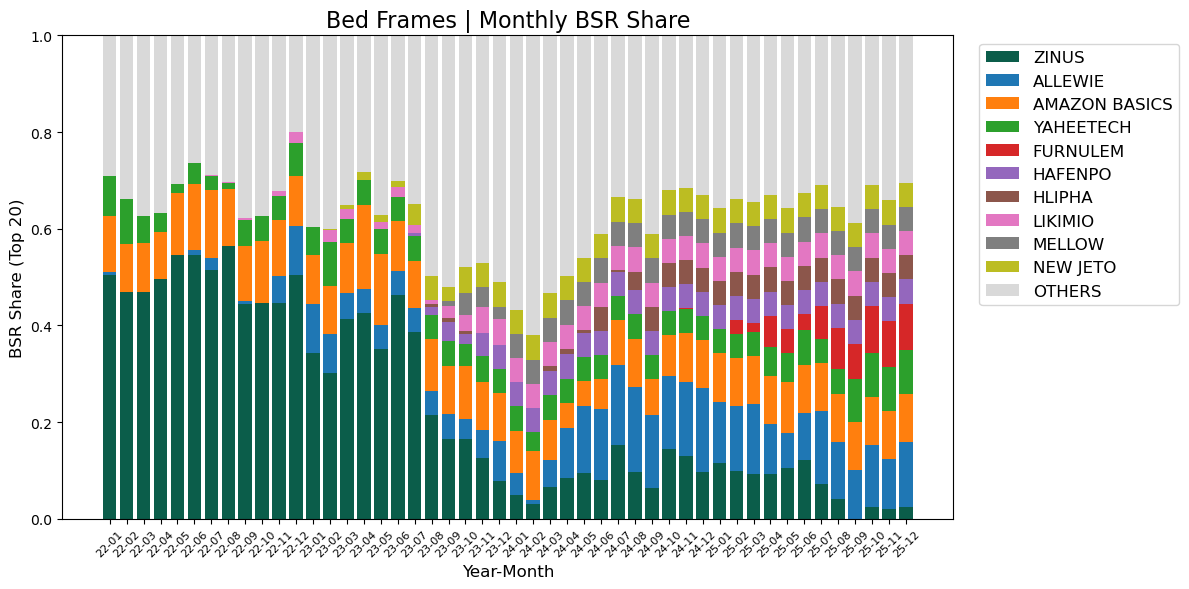

['ZINUS', 'SHA CERLIN', 'DICTAC', 'ADORNEVE', 'ALLEWIE', 'AMERLIFE', 'VINGLI', 'MELLOW', 'MILLIARD', 'JOCOEVOL', 'OTHERS']


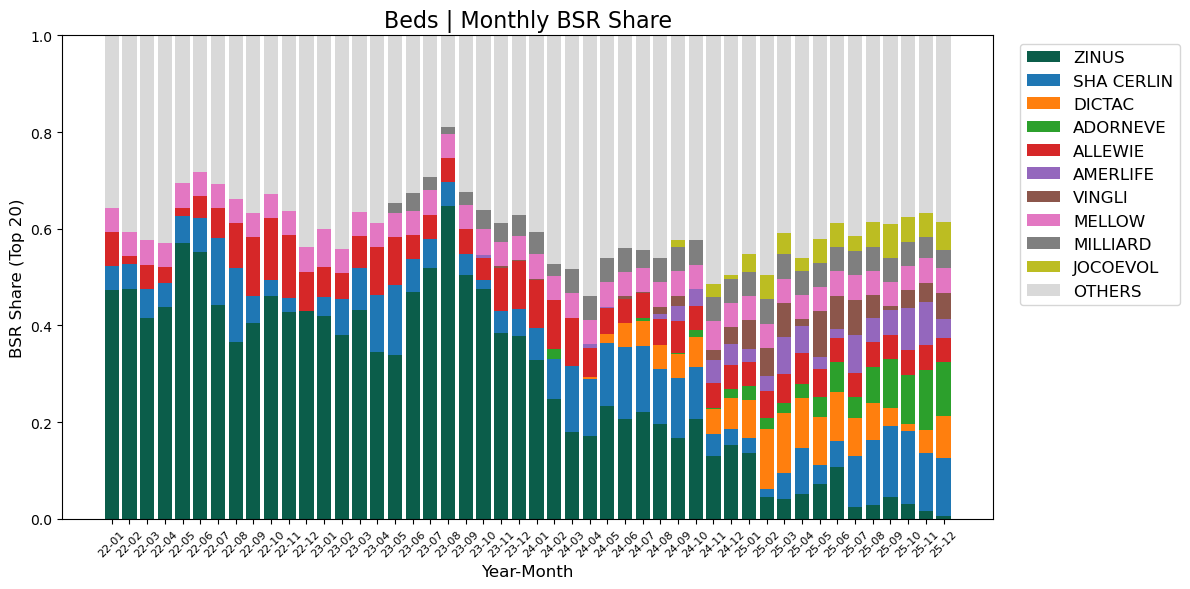

['ZINUS', 'NOVILLA', 'MLILY', 'FDW', 'BEST PRICE MATTRESS', 'GAESTE', 'EGOHOME', 'MOLBIUS', 'ROLANSTAR', 'COOL GEL', 'OTHERS']


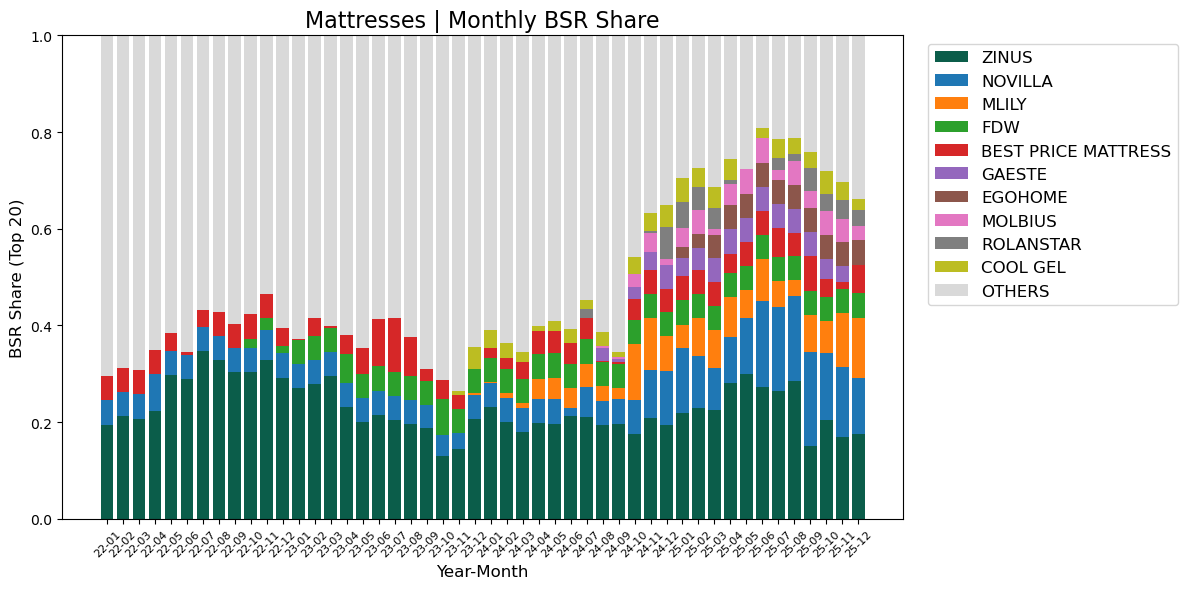

In [37]:
ZINUS_COLOR  = '#0B5D4A'   # dark jade
OTHERS_COLOR = '#D9D9D9'   # gray

df_plot = brand_share_m[brand_share_m['yr_month'] >= '22-01'].copy()

for cat, sub in df_plot.groupby('bsr_ctgry'):
    sub = sub.copy()

    # -----------------------------
    # (A) category별 2025 기준 brand 순서 계산
    # -----------------------------
    yrm = sub['yr_month'].astype(str)
    sub_2025 = sub[yrm.str.startswith('2025') | yrm.str.startswith('25-')].copy()

    order_2025 = (
        sub_2025
        .groupby('brand_new')['bsr_share']
        .mean()
        .reset_index(name='ref_share')
    )

    zinus_list = ['ZINUS']
    others_list = ['OTHERS']

    rest_list = (
        order_2025[
            (order_2025['brand_new'] != 'ZINUS') &
            (order_2025['brand_new'] != 'OTHERS')
        ]
        .sort_values('ref_share', ascending=False)['brand_new']
        .tolist()
    )

    ordered_cols_base = zinus_list + rest_list + others_list  # ✅ category별 기준 순서
    print(ordered_cols_base)

    # -----------------------------
    # (B) pivot 만들고, 위 순서 적용
    # -----------------------------
    piv = (
        sub.pivot(index='yr_month', columns='brand_new', values='bsr_share')
           .fillna(0)
           .sort_index()
    )
    #print(piv)

    # 해당 piv에 실제로 존재하는 컬럼만 (안전)
    cols_in_piv = piv.columns.tolist()
    ordered_cols = [c for c in ordered_cols_base if c in cols_in_piv]

    # 2025에 없었지만 실제로 존재하는 브랜드(예: 2024만 등장) 뒤에 붙이기
    leftover = [c for c in cols_in_piv if c not in ordered_cols]
    ordered_cols = ordered_cols + leftover

    piv = piv[ordered_cols]
    # --- 누적 막대그래프 ---
    plt.figure(figsize=(12, 6))
    bottom = np.zeros(len(piv))

    for c in ordered_cols:
        c_up = str(c).strip().upper()

        values = piv[c].values
        x_pos = piv.index.astype(str)
        y_pos = bottom + values / 2

        if c_up == 'OTHERS':
            plt.bar(
                piv.index.astype(str), piv[c],
                bottom=bottom, label='OTHERS',
                color=OTHERS_COLOR
            )
        elif c_up == 'ZINUS':
            plt.bar(
                piv.index.astype(str), piv[c],
                bottom=bottom, label='ZINUS',
                color=ZINUS_COLOR
            )
        else:
            plt.bar(
                piv.index.astype(str), piv[c],
                bottom=bottom, label=str(c)
            )

        if False: # 주석 처리      
            # ✅ 퍼센트 라벨 표시 (1% 이상만)
            for i, v in enumerate(values):
                if v >= 0.05:  # 1% 미만은 표시 안 함
                    plt.text(
                        x_pos[i],
                        y_pos[i],
                        f"{v*100:.1f}%",
                        ha='center',
                        va='center',
                        fontsize=5,
                        color='white' if c_up != 'OTHERS' else 'black',
                        fontweight='bold'
                    )
   
        bottom = bottom + values

    plt.title(f"{cat} | Monthly BSR Share", fontsize=16)
    plt.xlabel("Year-Month", fontsize=12)
    plt.ylabel("BSR Share (Top 20)", fontsize=12)
    plt.ylim(0, 1)

    plt.xticks(rotation=45, fontsize=8)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=12)
    plt.tight_layout()
    plt.show()

#### 2. Review rating, review count, Price, 1P3P

In [13]:
df2 = df_bsr.copy()

df2['bsr_date'] = pd.to_datetime(df2['bsr_date'], errors='coerce')
df2['year'] = df2['bsr_date'].dt.year

In [15]:
print(df2)

       parent_asin   bsr_ctgry        asin  rank   bsr_date   brand brand_raw  \
0       B079V2216W        Beds  B079V2216W    12 2022-12-06  Others    Others   
1       B0CB5XFRB4        Beds  B09QL28HYV    14 2022-12-06  Others    Others   
2       B0CSZLZM7L  Mattresses  B07ZKMYFJZ    15 2022-12-06  Others    Others   
3       B084Q4Z5ZJ        Beds  B081HXZ5NK     4 2022-12-06  Others    Others   
4       B01L3L9WB2  Mattresses  B01L3L9WB2    19 2022-12-06  Others    Others   
...            ...         ...         ...   ...        ...     ...       ...   
108393  B08NXZHBC1        Beds  B08NXZHBC1    20 2021-01-01   ZINUS     ZINUS   
108394  B09W92CB8Y        Beds  B071RPDB4W    13 2021-01-01   ZINUS     ZINUS   
108395  B0DDXJLFWD  Bed Frames  B072Q4PX1R    20 2021-01-01   ZINUS     ZINUS   
108396  B0CM71Z3VS  Bed Frames  B06WW5G6GY    10 2021-01-01   ZINUS     ZINUS   
108397  B0DYZ28XZV  Mattresses  B074QTSBS2     2 2021-01-01   ZINUS     ZINUS   

       brand_raw_org       

In [21]:
categories = ['Beds', 'Bed Frames', 'Mattresses']

top10_brand_2025 = {
    cat: get_brand_share_by_category(df2, category=cat, year=2025)
    for cat in categories
}

In [95]:
#print(top10_brand_2025)
top10_brand_2025['Mattresses']

,brand_raw_org,bsr_cnt,cat_total_cnt,bsr_share,bsr_share_pct
108,ZINUS,1688,7300,0.231233,23.123288
67,NOVILLA,1012,7300,0.138630,13.863014
59,MLILY,543,7300,0.074384,7.438356
35,FDW,365,7300,0.050000,5.000000
10,BEST PRICE MATTRESS,353,7300,0.048356,4.835616
30,EGOHOME,334,7300,0.045753,4.575342
39,GAESTE,309,7300,0.042329,4.232877
60,MOLBIUS,290,7300,0.039726,3.972603
18,COOL GEL,250,7300,0.034247,3.424658
78,ROLANSTAR,209,7300,0.028630,2.863014


In [97]:
# Category별로 Top Brand의 data 추출하기
df_2025 = df2[df2['year']==2025].copy()

for cat, df_top10 in top10_brand_2025.items():
    if cat != 'Mattresses': 
        continue

    top_brands = df_top10['brand_raw_org'].unique().tolist()
    
    # ① 해당 category만 필터링
    df_cat = df_2025[df_2025['bsr_ctgry'] == cat].copy()
    if df_cat.empty:
        continue

    # ② 해당 category의 Top10 브랜드만 필터링
    df_cat_top10 = df_cat[df_cat['brand_raw_org'].isin(top_brands)].copy()

    # 동일 시간 중복이면 "마지막"이 남도록 정렬 후 tail(1)
    df_cat_top10 = df_cat_top10.sort_values(['asin', 'bsr_date'])

    #df_cat_top10[df_cat_top10['brand_raw_org']=='ZINUS'].to_csv('test_0113.csv')

    df_latest = (
        df_cat_top10
        .groupby(['bsr_ctgry','asin'], as_index=False)
        .tail(1)
    )
    
    # 1) (category, brand)별 seller_type(1P/2P/3P) ASIN 개수 → wide 형태
    seller_cnt = (
        df_latest
        .pivot_table(
            index=['bsr_ctgry', 'brand_raw_org'],
            columns='seller_type',
            values='asin',
            aggfunc=pd.Series.nunique,
            fill_value=0
        )
        .reset_index()
    )
    #print(seller_cnt)

        # 2) 평균 지표 계산
    metrics = (
        #df_latest
        df_cat_top10
        .groupby(['bsr_ctgry', 'brand_raw_org'], as_index=False)
        .agg(
            avg_rank=('rank', 'mean'),
            avg_rating=('rating', 'mean'),
            avg_retail_price=('retail_price', 'mean'),
            product_cnt=('asin', 'nunique'),   # 전체 ASIN 수(참고용)

            #seller type ratio
            seller_cnt=('seller_type', 'size'), 
            oneP_ratio=('seller_type', lambda x: (x=='1P').mean()),
            threeP_ratio=('seller_type', lambda x: (x=='3P').mean())
        )
    )
    #print(metrics)   

    # 3) 결합
    result = (
        metrics
        .merge(seller_cnt, on=['bsr_ctgry', 'brand_raw_org'], how='left')
    )

    print(result) 
    #print(f"\n==== Category: {cat} | unique_asin={df_latest['asin'].nunique()} ====\n\n")    

    bsr_ctgry        brand_raw_org   avg_rank  avg_rating  avg_retail_price  \
0  Mattresses  BEST PRICE MATTRESS  10.747875    4.327616        100.499678   
1  Mattresses             COOL GEL     15.048    4.455600        494.900200   
2  Mattresses              EGOHOME   4.443114    4.571903        119.315378   
3  Mattresses                  FDW   1.879452    4.400000         96.612521   
4  Mattresses               GAESTE    7.12945    4.500324        129.954272   
5  Mattresses                MLILY  14.593002    4.404972        344.252486   
6  Mattresses              MOLBIUS  10.113793    4.335069        156.272222   
7  Mattresses              NOVILLA  10.013834    4.431017        199.643867   
8  Mattresses            ROLANSTAR  14.784689    4.611058         64.869808   
9  Mattresses                ZINUS   7.244076    4.340284        141.891321   

   product_cnt  seller_cnt  oneP_ratio  threeP_ratio  1P  3P  
0           12         353    0.779037      0.195467   5   7  
1   

#### 3. Brand별 매출 

In [51]:
df3 = df_bsr.copy()

df3['bsr_date'] = pd.to_datetime(df3['bsr_date'], errors='coerce')
df3['year'] = df3['bsr_date'].dt.year

In [53]:
print(df3)

       parent_asin   bsr_ctgry        asin  rank   bsr_date   brand brand_raw  \
0       B079V2216W        Beds  B079V2216W    12 2022-12-06  Others    Others   
1       B0CB5XFRB4        Beds  B09QL28HYV    14 2022-12-06  Others    Others   
2       B0CSZLZM7L  Mattresses  B07ZKMYFJZ    15 2022-12-06  Others    Others   
3       B084Q4Z5ZJ        Beds  B081HXZ5NK     4 2022-12-06  Others    Others   
4       B01L3L9WB2  Mattresses  B01L3L9WB2    19 2022-12-06  Others    Others   
...            ...         ...         ...   ...        ...     ...       ...   
108393  B08NXZHBC1        Beds  B08NXZHBC1    20 2021-01-01   ZINUS     ZINUS   
108394  B09W92CB8Y        Beds  B071RPDB4W    13 2021-01-01   ZINUS     ZINUS   
108395  B0DDXJLFWD  Bed Frames  B072Q4PX1R    20 2021-01-01   ZINUS     ZINUS   
108396  B0CM71Z3VS  Bed Frames  B06WW5G6GY    10 2021-01-01   ZINUS     ZINUS   
108397  B0DYZ28XZV  Mattresses  B074QTSBS2     2 2021-01-01   ZINUS     ZINUS   

       brand_raw_org       

In [55]:
categories = ['Beds', 'Bed Frames', 'Mattresses']

top10_2025 = {
    cat: get_brand_share_by_category(df3, category=cat, year=2025)
    for cat in categories
}

In [57]:
for cat, df_top in top10_2025.items():
    top10_2025[cat]['brand_raw_org'] = (
        df_top['brand_raw_org']
        .replace({'AMAZON BASICS': 'AMAZONBASICS'})
    )

In [65]:
top10_2025['Beds']

,brand_raw_org,bsr_cnt,cat_total_cnt,bsr_share,bsr_share_pct
59,SHA CERLIN,652,7300,0.089315,8.931507
15,DICTAC,590,7300,0.080822,8.082192
1,ADORNEVE,464,7300,0.063562,6.356164
2,ALLEWIE,389,7300,0.053288,5.328767
3,AMERLIFE,386,7300,0.052877,5.287671
72,VINGLI,383,7300,0.052466,5.246575
47,MELLOW,365,7300,0.050000,5.000000
79,ZINUS,365,7300,0.050000,5.000000
48,MILLIARD,355,7300,0.048630,4.863014
35,JOCOEVOL,345,7300,0.047260,4.726027


In [99]:
# Get 2025 sales of top brands
df_sales['Brand_up'] = df_sales['Brand'].str.upper().str.strip()

for cat, df_top10 in top10_2025.items():
    if cat != 'Mattresses': 
        continue
    #df_top10['brand_raw_org'] = df['brand_raw_org'].replace({'AMAZON BASICS':'AMAZONBASICS'})

    top_brands = df_top10['brand_raw_org'].unique().tolist()
    print(top_brands)

    # ① 해당 category만 필터링
    df_cat = df_sales[df_sales['SubCategory'] == cat].copy()
    if df_cat.empty:
        continue
    
    # ② 해당 category의 Top10 브랜드만 필터링
    df_cat_top10 = df_cat[df_cat['Brand_up'].isin(top_brands)].copy()

    # 2) Brand별 매출 합
    top_brand_sales = (
        df_cat_top10
        .groupby(['SubCategory', 'Brand_up'], as_index=False)
        .agg(
            sales=('RetailSales', 'sum'),
            qty=('UnitsSold', 'sum')
        )
        .sort_values('sales', ascending=False)
    )

    top_brand_sales['sales'] = top_brand_sales['sales'].map('{:,.0f}'.format)
    print(top_brand_sales)

['ZINUS', 'NOVILLA', 'MLILY', 'FDW', 'BEST PRICE MATTRESS', 'EGOHOME', 'GAESTE', 'MOLBIUS', 'COOL GEL', 'ROLANSTAR']
  SubCategory             Brand_up        sales      qty
9  Mattresses                ZINUS  263,826,019  1611652
7  Mattresses              NOVILLA  144,837,935   759015
5  Mattresses                MLILY   70,791,829   231915
3  Mattresses                  FDW   68,494,007   549184
2  Mattresses              EGOHOME   44,551,376   393937
1  Mattresses             COOL GEL   34,253,857   100460
4  Mattresses               GAESTE   28,800,432   209900
0  Mattresses  BEST PRICE MATTRESS   22,194,394   195394
6  Mattresses              MOLBIUS   19,956,240   122778
8  Mattresses            ROLANSTAR   10,637,370   108205
